Saving bleach.png to bleach.png


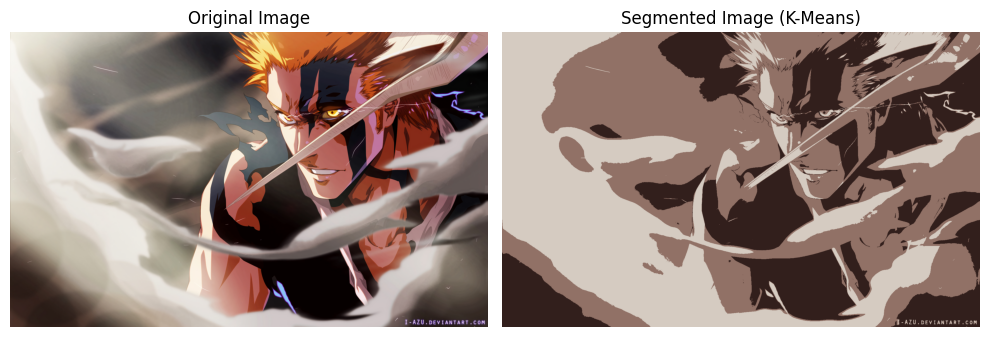

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import files

# Upload image from computer
uploaded = files.upload()

# Get uploaded image filename
filename = next(iter(uploaded))

# Read image
img = cv2.imread(filename)

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load the image.")
else:
    # Convert BGR to RGB
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Reshape pixels
    pixels = np.float32(rgb_img.reshape((-1, 3)))

    # K-Means criteria
    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        100,
        0.2
    )

    # Number of clusters
    K = 3

    # Apply K-Means clustering
    _, labels, centers = cv2.kmeans(
        pixels,
        K,
        None,
        criteria,
        10,
        cv2.KMEANS_RANDOM_CENTERS
    )

    # Convert centers to 8-bit
    centers = np.uint8(centers)

    # Create segmented image
    segmented_img = centers[labels.flatten()].reshape(rgb_img.shape)

    # Display images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(segmented_img)
    plt.title("Segmented Image (K-Means)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()